# EpiCoV EDA for 2025

- Number of sequences: `50,000`
- Collection date range: 1 Jan 2025 to 12 Mar 2025
- Submission date range: 6 Jan 2025 to 27 Jun 2025

In [1]:
# General
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Custom helpers
from utils import (standardize_country_name, get_continent, choropleth_continent,
choropleth_world, map_age_to_group, col_fillna, plot_dominant_choropleth)

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = "~/gcs-buckets"
YEAR = "2025"
PLOTS_PATH = "epicov2025_plots/1Jan25_30Apr25_collection/"

In [3]:
%%time
FILEPATH = os.path.join(DATA_PATH, "1Jan25_30Apr25_collected.csv")
params = {"filepath_or_buffer":FILEPATH, "sep": "," if FILEPATH.endswith(".csv") else "\t"}
df = pd.read_csv(**params)
df.sort_values(by=["Collection date"], inplace=True)
num_rows = 50000
if df.shape[0] > num_rows:
    print(f"Limiting dataset to first {num_rows} rows for testing.")
    df = df.iloc[:num_rows, :]
df.shape, df.info()

Limiting dataset to first 50000 rows for testing.
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 47072 to 57705
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Accession ID                     50000 non-null  object
 1   Submission date                  50000 non-null  object
 2   Virus name                       50000 non-null  object
 3   Collection date                  50000 non-null  object
 4   Location                         50000 non-null  object
 5   Host                             50000 non-null  object
 6   Additional location information  379 non-null    object
 7   Sampling strategy                18833 non-null  object
 8   Gender                           50000 non-null  object
 9   Patient age                      50000 non-null  object
 10  Patient status                   50000 non-null  object
 11  Last vaccinated                  417 non-nul

((50000, 18), None)

In [4]:
df["Submission date"] = pd.to_datetime(df["Submission date"], format="mixed")
df["Submission date"].min(), df["Submission date"].max()

(Timestamp('2025-01-06 00:00:00'), Timestamp('2025-06-27 00:00:00'))

In [5]:
df["submission_yr"] = df["Submission date"].dt.strftime("%Y")
df["submission_yr"].value_counts().sort_index()

submission_yr
2025    50000
Name: count, dtype: int64

In [6]:
df["Collection date"] = pd.to_datetime(df["Collection date"], format="mixed")
df["Collection date"].min(), df["Collection date"].max()

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-03-12 00:00:00'))

In [7]:
df["collection_yr"] = df["Collection date"].dt.strftime("%Y")
df["collection_yr"].value_counts().sort_index()

collection_yr
2025    50000
Name: count, dtype: int64

Let us validate if `Submission_date` is after the `Collection_date`

In [8]:
df[df["Collection date"] > df["Submission date"]].shape

(0, 20)

Find average time between collection of sample and submission of sequence collected on or after Jan 2020

In [9]:
df = df[df["Collection date"] >= pd.to_datetime("2020-01-01")]
df["collection_to_submission_days"] = (df["Submission date"] - df["Collection date"]).dt.days
df["collection_to_submission_days"].describe()

count    50000.000000
mean        37.014560
std         32.724652
min          1.000000
25%         16.000000
50%         24.000000
75%         45.000000
max        177.000000
Name: collection_to_submission_days, dtype: float64

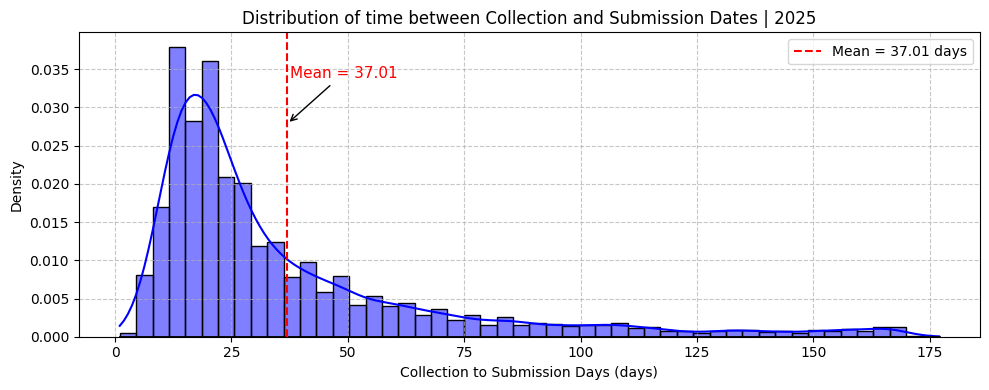

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df["collection_to_submission_days"], bins=50, kde=True, color='blue', stat='density')
sns.lineplot(x=sorted(df["collection_to_submission_days"]), 
             y=np.full(df.shape[0], 0), color='black', linewidth=2)
mean_days = df["collection_to_submission_days"].mean()
plt.axvline(mean_days, color='red', linestyle='--', label=f"Mean = {mean_days:.2f} days")

# Place annotation above the mean line, at the top of the plot
ymax = plt.gca().get_ylim()[1]
plt.annotate(f"Mean = {mean_days:.2f}", xy=(mean_days, ymax*0.7), xytext=(mean_days+0.5, ymax*0.85),
             arrowprops=dict(facecolor='red', arrowstyle='->'), color='red', fontsize=11)

plt.xlabel("Collection to Submission Days (days)")
plt.title(f"Distribution of time between Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_to_submission_days_distribution_{YEAR}.png"), dpi=300)
plt.show()

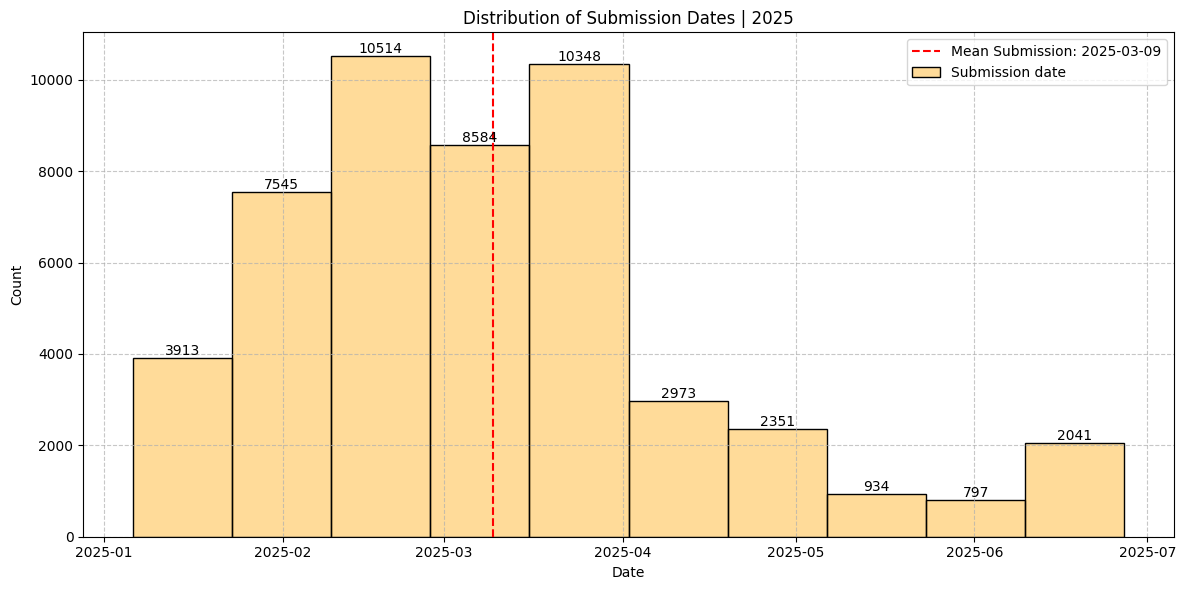

In [11]:
plt.figure(figsize=(12, 6))

# Plot histograms for submission dates
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.4)

# Calculate means
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"submission_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

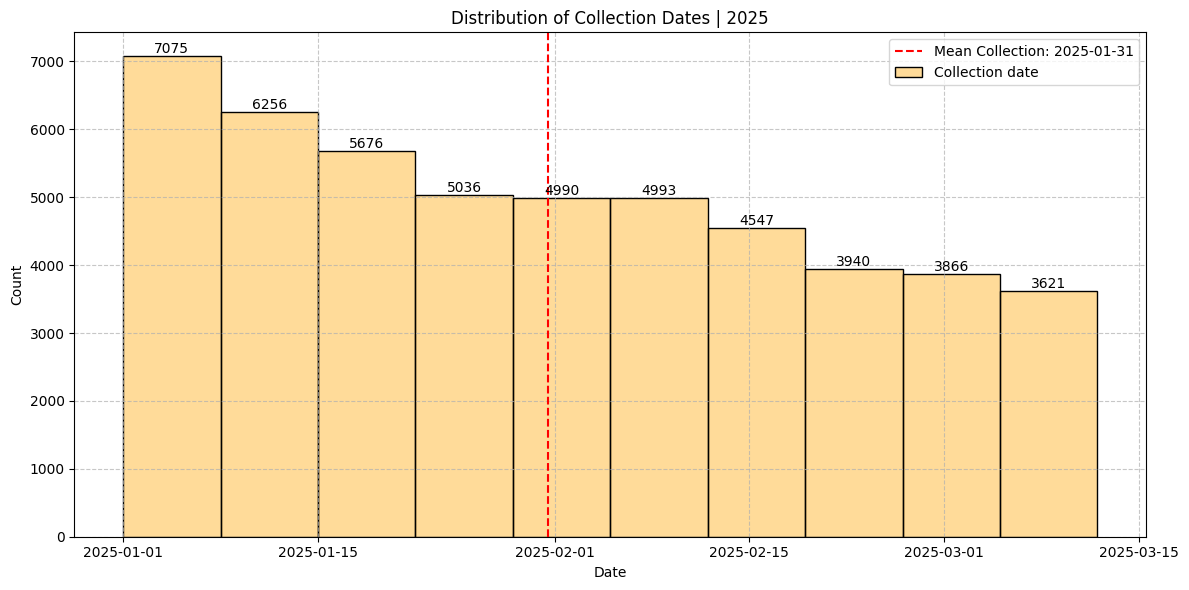

In [12]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection dates
sns.histplot(df["Collection date"], bins=10, color="orange", label="Collection date", kde=False, alpha=0.4)

# Calculate means
mean_collection = df["Collection date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="red", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")

# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_dates_spread_{YEAR}.png"), dpi=300)
plt.show()

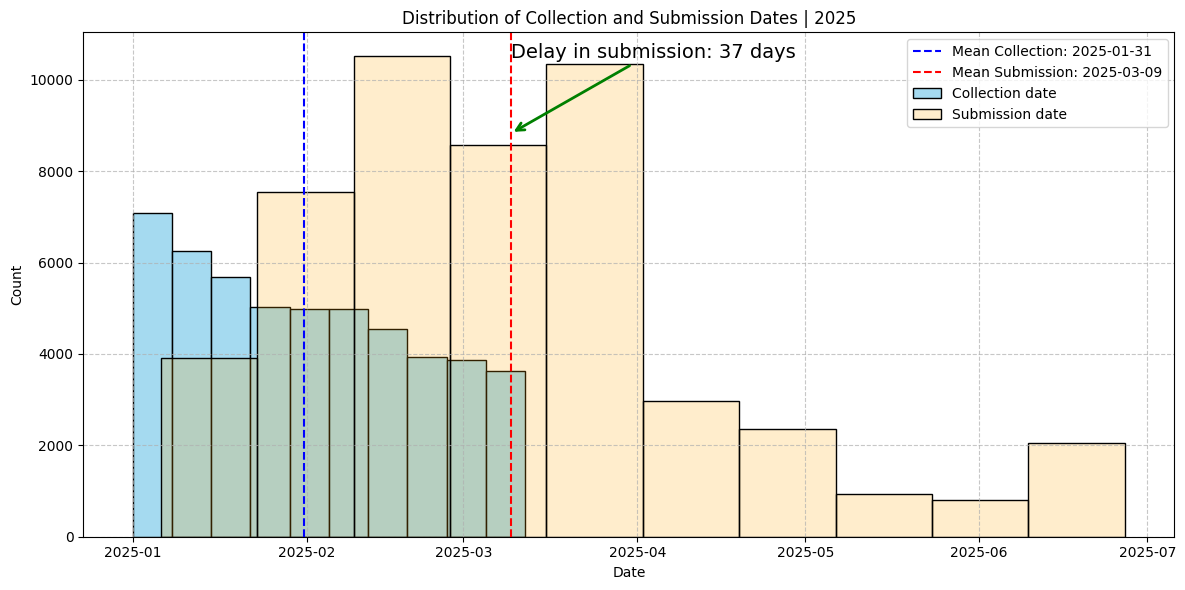

In [13]:
plt.figure(figsize=(12, 6))

# Plot histograms for collection and submission dates
sns.histplot(df["Collection date"], bins=10, color="skyblue", label="Collection date", kde=False)
sns.histplot(df["Submission date"], bins=10, color="orange", label="Submission date", kde=False, alpha=0.2)

# Calculate means
mean_collection = df["Collection date"].mean()
mean_submission = df["Submission date"].mean()

# Plot mean lines
plt.axvline(mean_collection, color="blue", linestyle="--", label=f"Mean Collection: {mean_collection.date()}")
plt.axvline(mean_submission, color="red", linestyle="--", label=f"Mean Submission: {mean_submission.date()}")

# Annotate lead time
lead_time = (mean_submission - mean_collection).days
plt.annotate(
    f"Delay in submission: {lead_time} days",
    xy=(mean_submission, plt.ylim()[1]*0.8),
    xytext=(mean_submission, plt.ylim()[1]*0.95),
    arrowprops=dict(facecolor='green', edgecolor='green', arrowstyle='->', lw=2),
    color="black",
    fontsize=14,
    ha='left'
)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title(f"Distribution of Collection and Submission Dates | {YEAR}")
plt.legend()
plt.tight_layout()
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PLOTS_PATH, f"collection_submission_dates_distribution_{YEAR}.png"), dpi=300)
plt.show()

In [14]:
df["Gender"].value_counts()

Gender
unknown                   26221
Female                    13561
Male                      10166
unknow                       36
73                            2
69                            2
5 m                           2
not collected                 1
45                            1
93                            1
Non-binary/trans other        1
83                            1
72                            1
94                            1
65                            1
77                            1
96                            1
Name: count, dtype: int64

In [15]:
df["Patient status"].value_counts()

Patient status
unknown                    48291
Live                         554
Hospitalized                 302
Symptomatic                  226
Alive                        148
Released                     113
live                          97
Ambulatory                    39
hospitalized                  37
Asymptomatic; Recovered       32
Non hospitalized              32
non hospitalized              30
SRAG                          19
Asymptomatic                  17
Sentinela                     14
Outpatient                    11
Deceased                       8
not collected                  5
Severe; Recovered              4
unkown                         4
Released, Live                 4
Severe                         4
Death                          3
Non-hospitalized               2
Asymptomatic; Deceased         2
In patient                     1
Recovered                      1
Name: count, dtype: int64

In [16]:
df["Patient age"].value_counts()

Patient age
unknown        24140
85-89           1001
90-94            828
80-84            810
0                707
               ...  
41-46              1
20-25              1
30 years           1
64-69 years        1
25 years           1
Name: count, Length: 419, dtype: int64

In [17]:
df[~df["Gender"].isin(["Male", "Female", "unknown", "unknow", "not collected", "Non-binary/trans other"])]

,Accession ID,Submission date,Virus name,Collection date,Location,Host,Additional location information,Sampling strategy,Gender,Patient age,...,Last vaccinated,Passage,Specimen,Additional host information,Lineage,Clade,AA Substitutions,submission_yr,collection_yr,collection_to_submission_days
36087,EPI_ISL_19751062,2025-02-26,hCoV-19/Spain/CB-HUMV-5424315/2025,2025-01-17,Europe / Spain / Cantabria,Human,NaN,NaN,73,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2025,2025,40
32440,EPI_ISL_19751061,2025-02-26,hCoV-19/Spain/CB-HUMV-5424388/2025,2025-01-18,Europe / Spain / Cantabria,Human,NaN,NaN,45,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,39
55423,EPI_ISL_19751060,2025-02-26,hCoV-19/Spain/CB-HUMV-8812596/2025,2025-01-24,Europe / Spain / Cantabria,Human,NaN,NaN,93,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_T1465I,Spike_L24...",2025,2025,33
55424,EPI_ISL_19751059,2025-02-26,hCoV-19/Spain/CB-HUMV-8817108/2025,2025-01-30,Europe / Spain / Cantabria,Human,NaN,NaN,73,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,27
52546,EPI_ISL_19751058,2025-02-26,hCoV-19/Spain/CB-HUMV-5431271/2025,2025-01-31,Europe / Spain / Cantabria,Human,NaN,NaN,5 m,Male,...,NaN,Original,NaN,NaN,JN.1,GRA,"(Spike_H69del,NS7b_F19L,Spike_S50L,NSP3_G489S,...",2025,2025,26
25851,EPI_ISL_19751057,2025-02-26,hCoV-19/Spain/CB-HUMV-8822025/2025,2025-02-03,Europe / Spain / Cantabria,Human,NaN,NaN,72,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,23
27922,EPI_ISL_19751056,2025-02-26,hCoV-19/Spain/CB-HUMV-5447091/2025,2025-02-05,Europe / Spain / Cantabria,Human,NaN,NaN,69,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,Spike_L24del,NSP3_G48...",2025,2025,21
27921,EPI_ISL_19751055,2025-02-26,hCoV-19/Spain/CB-HUMV-5431716/2025,2025-02-06,Europe / Spain / Cantabria,Human,NaN,NaN,5 m,Male,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2025,2025,20
27917,EPI_ISL_19751051,2025-02-26,hCoV-19/Spain/CB-HUMV-21761119/2025,2025-02-07,Europe / Spain / Cantabria,Human,NaN,NaN,83,Female,...,NaN,Original,NaN,NaN,JN.1.16 (consensus call),GRA,"(Spike_H69del,NSP3_G489S,Spike_L24del,NSP4_T32...",2025,2025,19
27920,EPI_ISL_19751054,2025-02-26,hCoV-19/Spain/CB-HUMV-5447216/2025,2025-02-08,Europe / Spain / Cantabria,Human,NaN,NaN,94,Female,...,NaN,Original,NaN,NaN,XEC (consensus call),GRA,"(NSP5_P132H,Spike_H69del,NSP3_G489S,Spike_L24d...",2025,2025,18


In [18]:
# Swap the two values in these rows (Patient age and Patent gender)
for i, row in df[~df["Gender"].isin(["Male", "Female", "unknown", "unknow", "not collected", "Non-binary/trans other"])].iterrows():
    age = row["Patient age"]
    df.at[i, "Patient age"] = row["Gender"]
    df.at[i, "Gender"] = age

In [19]:
df["Gender"].value_counts()

Gender
unknown                   26221
Female                    13568
Male                      10173
unknow                       36
not collected                 1
Non-binary/trans other        1
Name: count, dtype: int64

## Geographical distribution

Let's see the geographical distribution of various parameters

In [20]:
(print(set([x.split("/")[0] for x in df["Location"].values.tolist()])), df.nunique())

{'Asia ', 'Africa ', 'South America ', 'Europe ', 'Oceania ', 'North America '}


(None,
 Accession ID                       50000
 Submission date                      154
 Virus name                         50000
 Collection date                       71
 Location                            1349
 Host                                   1
 Additional location information      126
 Sampling strategy                     51
 Gender                                 6
 Patient age                          418
 Patient status                        27
 Last vaccinated                      256
 Passage                                8
 Specimen                              67
 Additional host information          269
 Lineage                              712
 Clade                                  5
 AA Substitutions                   48506
 submission_yr                          1
 collection_yr                          1
 collection_to_submission_days        175
 dtype: int64)

Collate required columns

In [21]:
df1 = df[["Accession ID", "Location", "Gender", "Patient age", "Patient status"]].reset_index(drop=True)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Location        50000 non-null  object
 2   Gender          50000 non-null  object
 3   Patient age     50000 non-null  object
 4   Patient status  50000 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


Split location into `continent`, `country`, `state` and `city`

In [22]:
df1["continent"], df1["country"], df1["state"], df1["city"] = np.nan, np.nan, np.nan, np.nan

cols = ["continent", "country", "state", "city"]
for i, row in tqdm(df1.iterrows(), desc="Geographical information extraction", total=df1.shape[0]):
    loc = row["Location"]
    locs = [x.strip() for x in loc.split("/")]
    for j in range(min(len(locs),len(cols))):
        df1.loc[i, cols[j]] = locs[j]
df1.drop(columns=["Location"], inplace=True)
df1.info()

Geographical information extraction:   0%|          | 96/50000 [00:00<00:52, 953.80it/s]

Geographical information extraction: 100%|██████████| 50000/50000 [00:27<00:00, 1821.23it/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Accession ID    50000 non-null  object
 1   Gender          50000 non-null  object
 2   Patient age     50000 non-null  object
 3   Patient status  50000 non-null  object
 4   continent       50000 non-null  object
 5   country         50000 non-null  object
 6   state           46665 non-null  object
 7   city            11211 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


## Entries distribution countrywise

We look at number of entries from each country normalised by:
- country's population
- country's per capita income
- reported cases
- reported deaths

First let's create a dictionary containing country's metadata

In [23]:
df1["country"].nunique()

80

Countrywise population for 2025 from [Worldometer](https://www.worldometers.info/world-population/population-by-country/)

In [24]:
df_pop = pd.read_csv(os.path.join(DATA_PATH, "worldometer_population_by_country_2025.csv"))
df_pop.rename(columns={"Country (or dependency)": "country", "Population (2025)": "2025"}, inplace=True)
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          233 non-null    object 
 1   2025             233 non-null    int64  
 2   Yearly Change    233 non-null    object 
 3   Net Change       233 non-null    object 
 4   Density (P/Km²)  233 non-null    int64  
 5   Land Area (Km²)  233 non-null    int64  
 6   Migrants (net)   233 non-null    object 
 7   Fert. Rate       233 non-null    float64
 8   Median Age       233 non-null    float64
 9   Urban Pop %      210 non-null    object 
 10  World Share      233 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 20.2+ KB


In [25]:
(len(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist())),
 set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))

(4, {'Canary Islands', 'Cote d’Ivoire', 'Curacao', 'USA'})

In [26]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)]["country"].value_counts()

country
USA               21788
Canary Islands       31
Cote d’Ivoire         8
Curacao               4
Name: count, dtype: int64

A few countries like South Korea, Czech Republic etc have different alternative names used in the dataframes. Let us standardize it using the following snippet. Also, Population of Canary Islands is part of that of Spain - included in Spain

In [27]:
df1["country"] = df1["country"].str.replace("USA", "United States")
df1["country"] = df1["country"].str.replace("Cote d’Ivoire", "Cote d'Ivoire")
df1["country"] = df1["country"].str.replace("Canary Islands", "Spain")

In [28]:
df_pop["country"] = df_pop["country"].str.replace("Côte d'Ivoire", "Cote d'Ivoire")
df_pop["country"] = df_pop["country"].str.replace("Curaçao", "Curacao")

In [29]:
countries = df1["country"].unique()
country_meta = [{"country":x} for x in countries]
len(country_meta), country_meta[:3]

(79,
 [{'country': 'Canada'}, {'country': 'United States'}, {'country': 'Brazil'}])

In [30]:
focus = list(set(df1["country"].values.tolist()) -set(df_pop["country"].values.tolist()))
df1[df1["country"].isin(focus)].shape[0], df1[df1["country"].isin(focus)]["country"].value_counts()

(0, Series([], Name: count, dtype: int64))

In [31]:
# Fill in population data in country_meta
for x in tqdm(country_meta, desc="Filling population data"):
    country = x["country"]
    cont = df1[df1["country"]==country]["continent"].values[0]
    x["continent"] = cont
    if country in df_pop["country"].values.tolist():
        pop = df_pop[df_pop["country"]==country][YEAR].values[0]
        x["population"] = int(pop)
country_meta[:3]

Filling population data: 100%|██████████| 79/79 [00:00<00:00, 128.50it/s]


[{'country': 'Canada', 'continent': 'North America', 'population': 40126723},
 {'country': 'United States',
  'continent': 'North America',
  'population': 347275807},
 {'country': 'Brazil', 'continent': 'South America', 'population': 212812405}]

Collect only entries where population is non-zero => exclude Canary Islands as of now

In [32]:
skip_countries = ["Canary Islands", "Crimea"]
df2 = df1[~df1["country"].isin(skip_countries)]
df1.shape, df2.shape

((50000, 8), (50000, 8))

In [33]:
df2.to_csv(os.path.join(DATA_PATH, f"{YEAR}_cleaned.csv"), index=False)

### A. Normalising by country's population
#### A.1. Number of entries from each country

Let's first see how many entries are from different countries grouped by their continent

In [34]:
df_country = pd.DataFrame([x for x in country_meta if x["country"] not in ["Canary Islands","Crimea"]])
df_country.shape, df_country[df_country["population"].isnull()].shape

((79, 3), (0, 3))

In [35]:
sorted(df_pop["country"].unique().tolist())

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Caribbean Netherlands',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic (Czechia)',
 'DR Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Faeroe Islands',
 'Falkland Islands',
 'Fi

In [36]:
exclude = ["Africa (UN)", "Asia (UN)", "Americas (UN)", "Europe (UN)",
            "Oceania (UN)", "World", "High-income countries", "Land-locked developing countries (LLDC)",
            "Latin America and the Caribbean (UN)", "Least developed countries", "Less developed regions",
            "Less developed regions, excluding China", "Less developed regions, excluding least developed countries",
            "Low-income countries", "Lower-middle-income countries", "More developed regions", "Northern America (UN)",
            "Small island developing states (SIDS)", "Upper-middle-income countries"]
df_pop = df_pop[~df_pop["country"].isin(exclude)]
df_pop["country"].nunique()

233

In [37]:
df_merged = pd.merge(df_country, df_pop[["country", YEAR]], on="country", how="right")
df_merged.rename(columns={YEAR: f"population_{YEAR}"}, inplace=True)
df_merged.drop(columns=["population"], inplace=True)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          233 non-null    object
 1   continent        79 non-null     object
 2   population_2025  233 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 5.6+ KB


In [38]:
df_merged["country_standard"] = df_merged["country"].apply(standardize_country_name)
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           233 non-null    object
 1   continent         79 non-null     object
 2   population_2025   233 non-null    int64 
 3   country_standard  233 non-null    object
dtypes: int64(1), object(3)
memory usage: 7.4+ KB


In [39]:
df_merged["continent_x"] = df_merged["country_standard"].apply(get_continent)
df_merged["continent_x"].nunique(), df_merged["continent"].nunique()

(7, 6)

In [40]:
df_merged[df_merged["continent_x"]=="Unknown"]

,country,continent,population_2025,country_standard,continent_x
8,Russia,Europe,143997393,Russia,Unknown
14,DR Congo,NaN,112832473,DR Congo,Unknown
17,Turkey,Asia,87685426,Turkey,Unknown
91,Czech Republic (Czechia),NaN,10609239,Czech Republic (Czechia),Unknown
154,Timor-Leste,NaN,1418517,Timor-Leste,Unknown
170,Western Sahara,NaN,600904,Western Sahara,Unknown
174,Brunei,NaN,466330,Brunei,Unknown
194,Micronesia,NaN,113683,Micronesia,Unknown
197,St. Vincent & Grenadines,NaN,99924,St. Vincent & Grenadines,Unknown
199,U.S. Virgin Islands,NaN,84138,U.S. Virgin Islands,Unknown


In [41]:
for i, row in df_merged.iterrows():
    if row["continent_x"] == "Unknown" and not pd.isnull(row["continent"]):
        df_merged.at[i, "continent_x"] = row["continent"]
    
    if pd.isnull(row["continent"]) and row["continent_x"] != "Unknown":
        df_merged.at[i, "continent"] = row["continent_x"]

In [42]:
df_merged["continent"].unique(), df_merged["continent_x"].unique()

(array(['Asia', 'North America', 'Africa', 'South America', 'Europe', nan,
        'Oceania'], dtype=object),
 array(['Asia', 'North America', 'Africa', 'South America', 'Europe',
        'Unknown', 'Oceania'], dtype=object))

In [43]:
df_merged[df_merged["continent"].isna()]

,country,continent,population_2025,country_standard,continent_x
14,DR Congo,NaN,112832473,DR Congo,Unknown
91,Czech Republic (Czechia),NaN,10609239,Czech Republic (Czechia),Unknown
154,Timor-Leste,NaN,1418517,Timor-Leste,Unknown
170,Western Sahara,NaN,600904,Western Sahara,Unknown
174,Brunei,NaN,466330,Brunei,Unknown
194,Micronesia,NaN,113683,Micronesia,Unknown
197,St. Vincent & Grenadines,NaN,99924,St. Vincent & Grenadines,Unknown
199,U.S. Virgin Islands,NaN,84138,U.S. Virgin Islands,Unknown
210,Sint Maarten,NaN,43923,Sint Maarten,Unknown
218,Caribbean Netherlands,NaN,31338,Caribbean Netherlands,Unknown


In [44]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 188: Curacao - South America vs North America


We do the following assignment (based on Google search):

- `Azerbaijan` mostly in Western Asia. So we assign `Asia`
- `Curacao` is in `South America`
- `Cyprus` is in `Europe`

In [45]:
df_merged.loc[int(df_merged.index[df_merged["country"]=="Azerbaijan"][0]), "continent"] = "Asia"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Curacao"][0]), "continent_x"] = "South America"
df_merged.loc[int(df_merged.index[df_merged["country"]=="Cyprus"][0]), "continent_x"] = "Europe"

In [46]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           233 non-null    object
 1   continent         221 non-null    object
 2   population_2025   233 non-null    int64 
 3   country_standard  233 non-null    object
 4   continent_x       233 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.2+ KB


9 of the 237 entries have `Unknown` continent. Let's see which countries are these.

In [47]:
df_merged[df_merged["continent_x"] == "Unknown"]

,country,continent,population_2025,country_standard,continent_x
14,DR Congo,NaN,112832473,DR Congo,Unknown
91,Czech Republic (Czechia),NaN,10609239,Czech Republic (Czechia),Unknown
154,Timor-Leste,NaN,1418517,Timor-Leste,Unknown
170,Western Sahara,NaN,600904,Western Sahara,Unknown
174,Brunei,NaN,466330,Brunei,Unknown
194,Micronesia,NaN,113683,Micronesia,Unknown
197,St. Vincent & Grenadines,NaN,99924,St. Vincent & Grenadines,Unknown
199,U.S. Virgin Islands,NaN,84138,U.S. Virgin Islands,Unknown
210,Sint Maarten,NaN,43923,Sint Maarten,Unknown
218,Caribbean Netherlands,NaN,31338,Caribbean Netherlands,Unknown


Let's ignore these regions for now.

In [48]:
for i, row in df_merged.iterrows():
    if row["continent_x"] != "Unknown" and not pd.isnull(row["continent"]):
        if row["continent"] != row["continent_x"]:
            print(f"Mismatch at index {i}: {row['country']} - {row['continent']} vs {row['continent_x']}")

Mismatch at index 155: Cyprus - Asia vs Europe


In [49]:
df_merged = df_merged[df_merged["continent_x"] != "Unknown"].drop(columns=["continent_x"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 0 to 231
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   country           221 non-null    object
 1   continent         221 non-null    object
 2   population_2025   221 non-null    int64 
 3   country_standard  221 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.6+ KB


In [50]:
# Insert a new row for Antarctica into df_merged
antarctica_row = {
    "country": "Antarctica",
    "continent": "Antarctica",
    f"population_{YEAR}": 0,
    "country_standard": "Antarctica",
}
df_merged = pd.concat([df_merged, pd.DataFrame([antarctica_row])], ignore_index=True)
df_merged.tail()

,country,continent,population_2025,country_standard
217,Montserrat,North America,4359,Montserrat
218,Falkland Islands,Europe,3469,Åland Islands
219,Tokelau,Oceania,2608,Tokelau
220,Niue,Oceania,1821,Niue
221,Antarctica,Antarctica,0,Antarctica


In [51]:
df_merged["num_entries"] = float("NaN")

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        df_merged.loc[i, "num_entries"] = df2[df2["country"]==country].shape[0]
df_merged["num_entries"].describe()

count       79.000000
mean       632.911392
std       2654.725623
min          1.000000
25%          6.500000
50%         44.000000
75%        281.500000
max      21788.000000
Name: num_entries, dtype: float64

Now, we normalize the number of entries by the population of the country to get the comparison to be in a level playing field

In [52]:
# per lakh population
df_merged["num_entries_per_lakh"] = df_merged["num_entries"] / (df_merged[f"population_{YEAR}"] / 1e5)
df_merged.head()

,country,continent,population_2025,country_standard,num_entries,num_entries_per_lakh
0,India,Asia,1463865525,India,10.0,0.000683
1,China,Asia,1416096094,China,284.0,0.020055
2,United States,North America,347275807,United States,21788.0,6.273976
3,Indonesia,Asia,285721236,Indonesia,6.0,0.002100
4,Pakistan,Asia,255219554,Pakistan,2.0,0.000784


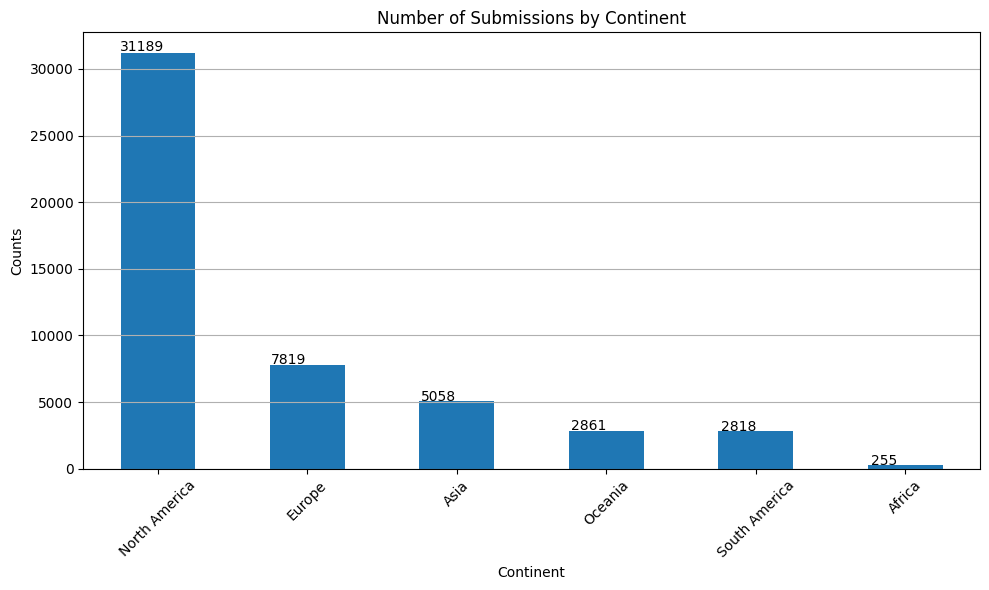

In [53]:
# Plot the bar chart
ax = df2["continent"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title('Number of Submissions by Continent')
plt.grid(axis= 'x')
plt.tight_layout()
plt.show()

In [54]:
df_merged["log_num_entries_per_lakh"] = np.log10(df_merged["num_entries_per_lakh"].replace(0, np.nan))
df_merged["log_num_entries_per_lakh"].describe()

count    79.000000
mean     -0.517525
std       1.140941
min      -3.165501
25%      -1.364604
50%      -0.428380
75%       0.398593
max       1.694832
Name: log_num_entries_per_lakh, dtype: float64

In [55]:
sign = -1 if df_merged["log_num_entries_per_lakh"].min() < 0 else 1
df_merged["log_num_entries_per_lakh"] = df_merged["log_num_entries_per_lakh"] + (df_merged["log_num_entries_per_lakh"].min() * sign)
df_merged["log_num_entries_per_lakh"].describe()

count    79.000000
mean      2.647976
std       1.140941
min       0.000000
25%       1.800897
50%       2.737121
75%       3.564094
max       4.860333
Name: log_num_entries_per_lakh, dtype: float64

In [56]:
# Fill NaN values with a sentinel value (e.g., 0) for visualization purposes
df_merged = col_fillna(df_merged, "log_num_entries_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_world(df_merged,
                        value_column='log_num_entries_per_lakh',
                        color_scale=custom_scale,
                        title=f'Submissions per Lakh Population (World) | Log 10 Scale | {YEAR}',
                        label='Submissions/Lakh (Log 10)',
                        hover_data={
                            f'population_{YEAR}': True,
                            'num_entries': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Plot per‐continent maps

In [57]:
# Define custom color scale including a gray value for the sentinel
custom_scale = [
    [0.0, "#d3d3d3"],    # NaN or sentinel value -> grey (to be masked in z values)
    [0.0001, "#313695"],  # dark blue for low log values
    [0.25,   "#74add1"],  # light blue
    [0.5,    "#ffffbf"],  # yellow (neutral / zero)
    [0.75,   "#f46d43"],  # orange
    [1.0,    "#a50026"]   # dark red for high log values
]

fig = choropleth_continent(df_merged,
                           value_column='log_num_entries_per_lakh',
                           color_scale=custom_scale,
                           title=f'Submissions per 1 Lakh Population by Continent | Log 10 Scale | {YEAR}',
                           label='Submissions/Lakh (Log 10)',
                           YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_entries_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

#### A.2. Gender distribution across countries

Let's next look at the gender distribution across countries again grouped by continents

In [58]:
df_merged["gender_m_per_lakh"], df_merged["gender_f_per_lakh"], df_merged["gender_u_per_lakh"] = float('nan'), float('nan'), float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "gender_m_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Male")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "gender_f_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "Female")].shape[0])/(row[f"population_{YEAR}"] / 1e5)
        df_merged.loc[i, "gender_u_per_lakh"] = (df2[(df2["country"] == country) & (df2["Gender"] == "unknown")].shape[0])/(row[f"population_{YEAR}"] / 1e5)

Convert to log 10 scale to show variation

In [59]:
df_merged["log_gender_m_per_lakh"] = np.log10(df_merged["gender_m_per_lakh"].replace(0, np.nan))
df_merged["log_gender_m_per_lakh"].describe()

count    59.000000
mean     -1.095757
std       1.053801
min      -3.320403
25%      -1.680188
50%      -1.067757
75%      -0.380175
max       1.294307
Name: log_gender_m_per_lakh, dtype: float64

In [60]:
sign = -1 if df_merged["log_gender_m_per_lakh"].min() < 0 else 1
df_merged["log_gender_m_per_lakh"] = df_merged["log_gender_m_per_lakh"] + (df_merged["log_gender_m_per_lakh"].min() * sign)
df_merged["log_gender_m_per_lakh"].describe()

count    59.000000
mean      2.224646
std       1.053801
min       0.000000
25%       1.640215
50%       2.252646
75%       2.940228
max       4.614710
Name: log_gender_m_per_lakh, dtype: float64

For choropleth maps, its better to have 3 different maps one for each gender. First we look at a zoomed out view of the whole world

In [61]:
# World map - distribution of males
df_merged = col_fillna(df_merged, "log_gender_m_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
male_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#cbdbfc"],  # very light blue
    [0.01, "#c6dbef"],
    [0.03, "#b3d1e6"],
    [0.06, "#9ecae1"],
    [0.12, "#6bb8d6"],
    [0.25, "#3182bd"],
    [0.5, "#08519c"],
    [1.0, "#08306b"]      # darkest blue
]


fig = choropleth_world(df_merged,
                       value_column="log_gender_m_per_lakh",
                       color_scale=male_scale,
                       title=f"Number of submissions from Males per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Males/1 lakh (Log 10)",
                       hover_data={
                            'gender_m_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we do for the entries submitted by females

In [62]:
df_merged["log_gender_f_per_lakh"] = np.log10(df_merged["gender_f_per_lakh"].replace(0, np.nan))
df_merged["log_gender_f_per_lakh"].describe()

count    62.000000
mean     -1.084330
std       1.102680
min      -3.688380
25%      -1.789765
50%      -1.187606
75%      -0.291957
max       1.472553
Name: log_gender_f_per_lakh, dtype: float64

In [63]:
sign = -1 if df_merged["log_gender_f_per_lakh"].min() < 0 else 1
df_merged["log_gender_f_per_lakh"] = df_merged["log_gender_f_per_lakh"] + (df_merged["log_gender_f_per_lakh"].min() * sign)
df_merged["log_gender_f_per_lakh"].describe()

count    62.000000
mean      2.604050
std       1.102680
min       0.000000
25%       1.898615
50%       2.500774
75%       3.396423
max       5.160933
Name: log_gender_f_per_lakh, dtype: float64

In [64]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_gender_f_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
female_scale = [
    [0.0, "#d3d3d3"],    # -1 or missing -> light grey
    [0.0001, "#ffb2d5"],  # very light pink
    [0.01, "#ffafcb"],
    [0.05, "#fa9fb5"],
    [0.1, "#f768a1"],
    [0.2, "#c51b8a"],
    [0.4, "#ae017e"],
    [1.0, "#7a0177"]   # darkest pink
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_f_per_lakh",
                       color_scale=female_scale,
                       title=f"Number of submissions from Females per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Females/1 lakh (Log 10)",
                       hover_data={
                            'gender_f_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [65]:
df_merged["log_gender_u_per_lakh"] = np.log10(df_merged["gender_u_per_lakh"].replace(0, np.nan))
df_merged["log_gender_u_per_lakh"].describe()

count    37.000000
mean     -0.417914
std       1.101034
min      -2.510192
25%      -1.524334
50%      -0.170388
75%       0.398139
max       1.034080
Name: log_gender_u_per_lakh, dtype: float64

In [66]:
sign = -1 if df_merged["log_gender_u_per_lakh"].min() < 0 else 1
df_merged["log_gender_u_per_lakh"] = df_merged["log_gender_u_per_lakh"] + (df_merged["log_gender_u_per_lakh"].min() * sign)
df_merged["log_gender_u_per_lakh"].describe()

count    37.000000
mean      2.092277
std       1.101034
min       0.000000
25%       0.985858
50%       2.339804
75%       2.908331
max       3.544272
Name: log_gender_u_per_lakh, dtype: float64

In [67]:
# World map - distribution of females
df_merged = col_fillna(df_merged, "log_gender_u_per_lakh", -1.0) # fill with -1.0 for NaN values

# Define custom color scale including a gray value for the sentinel
unknown_scale = [
    [0.0, "#d3d3d3"],    # missing -> light grey
    [0.0001, "#fff7e6"], # very pale tan
    [0.001, "#fee8c8"],  # very light tan
    [0.01, "#fdd49e"],   # light tan-orange
    [0.05, "#fdbb84"],   # medium golden tan
    [0.1, "#fdae6b"],    # deeper orange
    [0.2, "#fd8d3c"],    # orange
    [0.4, "#e6550d"],    # brown-orange
    [0.7, "#b35806"],    # brown
    [1.0, "#543005"]     # darkest brown
]

fig = choropleth_world(df_merged,
                       value_column="log_gender_u_per_lakh",
                       color_scale=unknown_scale,
                       title=f"Number of Unknown gender per Lakh Population (World) | Log 10 Scale | {YEAR}",
                       label="Missing gender/1 Lakh (Log 10)",
                       hover_data={
                            'gender_u_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_world_{YEAR}.html"))
fig.show()

Now we plot the continent-wise choropleth maps

In [68]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_m_per_lakh',
                           color_scale=male_scale,
                           title=f"Number of Submissions from males per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Males/1 Lakh (Log 10)",
                           YEAR = YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_males_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [69]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_f_per_lakh',
                           color_scale=female_scale,
                           title=f"Number of Submissions from females per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Females/1 Lakh (Log 10)",
                           YEAR=YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_females_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

In [70]:
fig = choropleth_continent(df_merged,
                           value_column='log_gender_u_per_lakh',
                           color_scale=unknown_scale,
                           title=f"Number of Submissions with missing gender per Lakh Population by Continent | Log 10 Scale | {YEAR}",
                           label="Unknown gender/1 Lakh (Log 10)",
                           YEAR=YEAR,
                           )

fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_unknown_gender_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see how the gender ratio is across continents and countries

In [71]:
df_merged["male_female_ratio"] = df_merged["gender_m_per_lakh"] / df_merged["gender_f_per_lakh"].replace(0, np.nan)
df_merged["male_female_ratio"].describe()

count    62.000000
mean      0.895687
std       0.648381
min       0.000000
25%       0.510542
50%       0.882836
75%       1.008947
max       4.200000
Name: male_female_ratio, dtype: float64

In [72]:
df_merged = col_fillna(df_merged, "male_female_ratio", -1.0) # fill with -1.0 for NaN values

custom_rdbu_with_gray = [
    [0.0, "#d3d3d3"],     # Missing / -1 → light gray
    [0.05, "#67001f"],    # Deep red (now at low end)
    [0.1, "#b2182b"],     # Red
    [0.33, "#f7f7f7"],    # White (neutral)
    [0.66, "#2166ac"],    # Blue
    [1.0, "#053061"]      # Deep blue (now at high end)
]

fig = choropleth_world(df_merged,
                       value_column="male_female_ratio",
                       color_scale=custom_rdbu_with_gray,
                       title=f"Male to Female ratio in total submissions (World) | {YEAR}",
                       label="Gender ratio",
                       hover_data={
                            'male_female_ratio': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_world_{YEAR}.html"))
fig.show()

In [73]:
fig = choropleth_continent(df_merged,
                           value_column='male_female_ratio',
                           color_scale=custom_rdbu_with_gray,
                           title="Male to Female ratio in total submissions (continent)",
                           label="Gender ratio",
                            hover_data={"male_female_ratio": True,
                                        f"population_{YEAR}": True,
                                        "country": False},
                            YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_male_female_ratio_continents_{YEAR}.html"))
fig.show()

Let us also see which gender submitted majority of the entries for each country on an absolute scale.

In [74]:
fig = plot_dominant_choropleth(
        df2,
        value_column='Gender',
        color_map={
            'Male': '#1f77b4',   # blue
            'Female': "#ff2eb9",   # pink,
            'unknown':'#bdbdbd',  # gray for unknown
            'unknow':'#bdbdbd'  # gray for unknown
        },
        title="Majority Gender"
    )
fig.show()

#### A.3. Patient status distribution across countries

Let's next look at the patient status distribution across countries again grouped by continents

In [75]:
len(list(df2["Patient status"].unique())), list(df2["Patient status"].unique())

(27,
 ['unknown',
  'Hospitalized',
  'Live',
  'Symptomatic',
  'Released',
  'Non-hospitalized',
  'hospitalized',
  'live',
  'Asymptomatic; Recovered',
  'non hospitalized',
  'Severe; Recovered',
  'Outpatient',
  'Deceased',
  'not collected',
  'In patient',
  'unkown',
  'Asymptomatic',
  'Non hospitalized',
  'Severe',
  'Ambulatory',
  'Death',
  'Alive',
  'SRAG',
  'Sentinela',
  'Asymptomatic; Deceased',
  'Released, Live',
  'Recovered'])

As we see there are a lot of overlapping categories. Let us group them together into meaningful categories as follows (reference: [WHO](https://onlinelibrary.wiley.com/cms/asset/d557561d-7c41-47f5-a5c6-db79e68988ad/tbed13892-fig-0003-m.jpg))

In [76]:
df_status_map = pd.read_excel(os.path.join(DATA_PATH, "patient_status_mapping_MLedit.xlsx"))
df_status_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   pat_stat             117 non-null    object
 1   clinical status      118 non-null    object
 2   hospitalized status  118 non-null    object
 3   severity             118 non-null    object
 4   category             118 non-null    object
 5   remarks              49 non-null     object
 6   further remarks      35 non-null     object
dtypes: object(7)
memory usage: 6.6+ KB


In [77]:
df_status_map[df_status_map["pat_stat"].isnull()]

,pat_stat,clinical status,hospitalized status,severity,category,remarks,further remarks
80,NaN,unknown,unknown,unknown,Unknown,NaN,NaN


In [78]:
len(set(df2["Patient status"].values.tolist())), len(set(df_status_map["pat_stat"].values.tolist()).intersection(set(df2["Patient status"].values.tolist())))

(27, 27)

In [79]:
df2["clinical_status"] = df2["Patient status"].apply(lambda x: df_status_map[df_status_map["pat_stat"]==x]["clinical status"].values[0] if x in df_status_map["pat_stat"].values else "unknown")
df2["clinical_status"].value_counts()

clinical_status
unknown      48300
active        1519
recovered      154
suspected       14
dead            13
Name: count, dtype: int64

In [80]:
df2["hospitalized"] = df2["Patient status"].apply(lambda x: df_status_map[df_status_map["pat_stat"]==x]["hospitalized status"].values[0] if x in df_status_map["pat_stat"].values else "unknown")
df2["hospitalized"].value_counts()

hospitalized
unknown        48306
no              1210
yes              480
usually yes        4
Name: count, dtype: int64

In [81]:
df2["severity"] = df2["Patient status"].apply(lambda x: df_status_map[df_status_map["pat_stat"]==x]["severity"].values[0] if x in df_status_map["pat_stat"].values else "unknown")
df2["severity"].value_counts()

severity
unknown                     48300
mild                         1156
moderate                      340
uninfected                    154
severe                         23
unknown - need that +RNA       14
dead                           13
Name: count, dtype: int64

- In `hospitalized` we group `usually yes` into `yes`
- In `severity` we group `unknown - need that +RNA` into `unknown`

In [82]:
for i, row in df2.iterrows():    
    # Hospitalized status
    if row["hospitalized"] in ["usually yes"]:
        df2.at[i, "hospitalized"] = "yes"
    
    # Severity
    if row["severity"] == "unknown - need that +RNA":
        df2.at[i, "severity"] = "unknown"

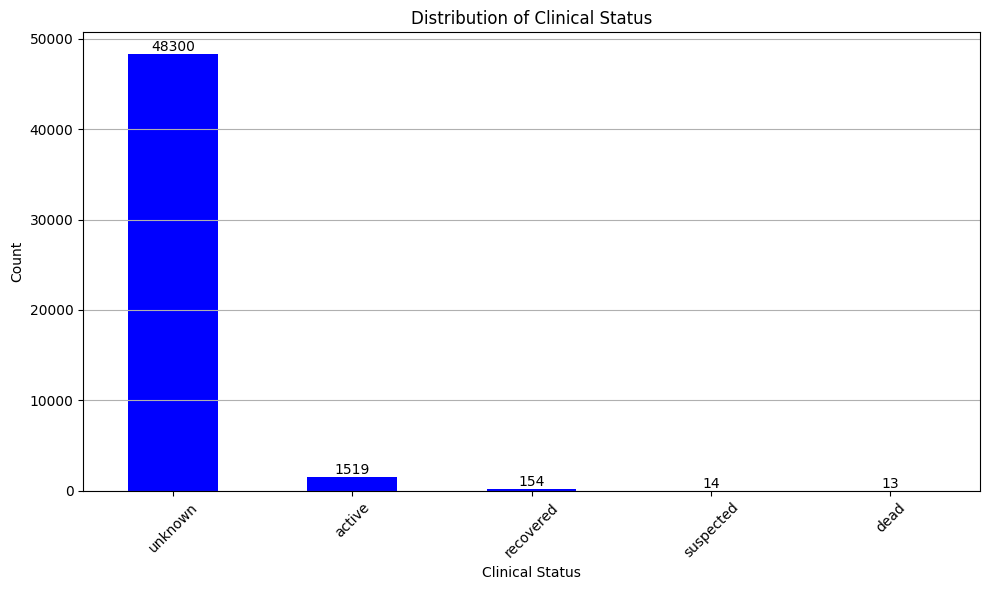

In [83]:
df2["clinical_status"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Clinical Status')
plt.ylabel('Count')
plt.title('Distribution of Clinical Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

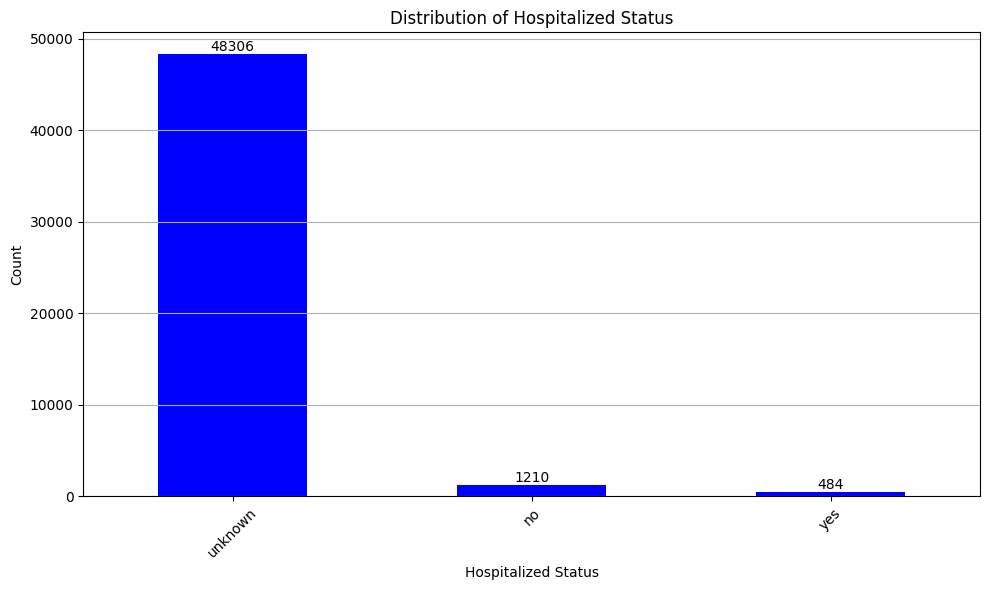

In [84]:
df2["hospitalized"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Hospitalized Status')
plt.ylabel('Count')
plt.title('Distribution of Hospitalized Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

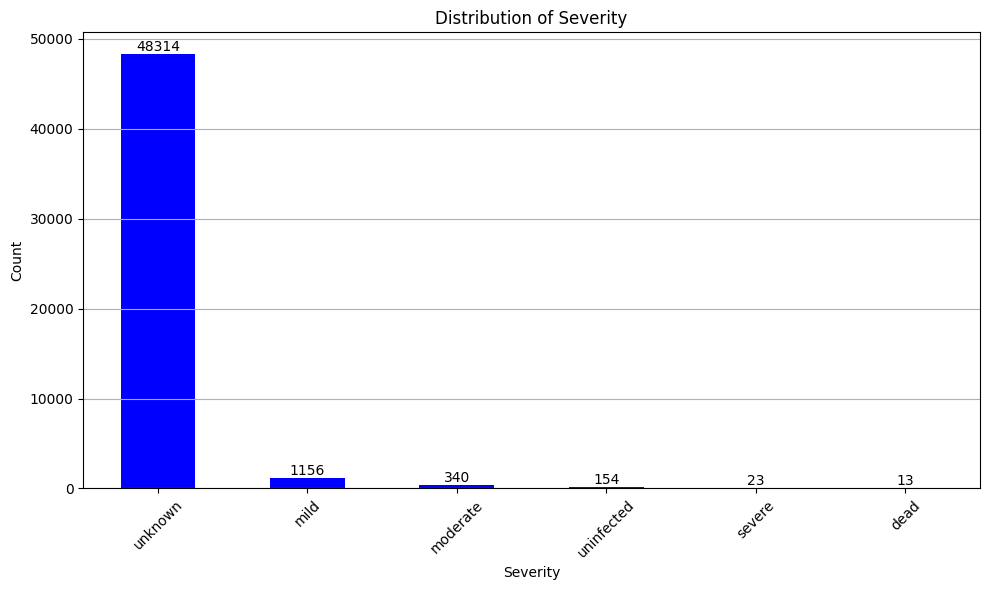

In [85]:
df2["severity"].value_counts().plot(kind='bar', figsize=(10, 6), color='blue')
# Annotate the bars
ax = plt.gca()
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xlabel('Severity')
plt.ylabel('Count')
plt.title('Distribution of Severity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [86]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Accession ID     50000 non-null  object
 1   Gender           50000 non-null  object
 2   Patient age      50000 non-null  object
 3   Patient status   50000 non-null  object
 4   continent        50000 non-null  object
 5   country          50000 non-null  object
 6   state            46665 non-null  object
 7   city             11211 non-null  object
 8   clinical_status  50000 non-null  object
 9   hospitalized     50000 non-null  object
 10  severity         50000 non-null  object
dtypes: object(11)
memory usage: 4.2+ MB


Let's first see how healthy each country is in terms of `clinical_status`

In [87]:
score_map = {"unknown": 0, "recovered": 1, "suspected": 2, "active": 3, "dead": 4}

In [88]:
df2["clinical_status_score"] = df2['clinical_status'].map(score_map)
df2["clinical_status_score"].describe()

count    50000.000000
mean         0.095820
std          0.522115
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: clinical_status_score, dtype: float64

In [89]:
df_merged["clinical_status_per_lakh"] = float('nan')

for i, row in df_merged.iterrows():
    country = row["country"]
    if country in df2["country"].values:
        # Calculate
        df_merged.loc[i, "clinical_status_per_lakh"] = (df2[(df2["country"] == country)]["clinical_status_score"].mean())/(row[f"population_{YEAR}"] / 1e5)
df_merged["clinical_status_per_lakh"].describe()

count    79.000000
mean      0.003556
std       0.010937
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000017
max       0.058883
Name: clinical_status_per_lakh, dtype: float64

In [90]:
df_merged["log_clinical_status_per_lakh"] = np.log10(df_merged["clinical_status_per_lakh"].replace(0, np.nan))
df_merged["log_clinical_status_per_lakh"].describe()

count    22.000000
mean     -2.632401
std       1.229891
min      -5.892770
25%      -3.085769
50%      -2.271167
75%      -1.799673
max      -1.230013
Name: log_clinical_status_per_lakh, dtype: float64

In [91]:
sign = -1 if df_merged["log_clinical_status_per_lakh"].min() < 0 else 1
df_merged["log_clinical_status_per_lakh"] = df_merged["log_clinical_status_per_lakh"] + (df_merged["log_clinical_status_per_lakh"].min() * sign)
df_merged["log_clinical_status_per_lakh"].describe()

count    22.000000
mean      3.260370
std       1.229891
min       0.000000
25%       2.807002
50%       3.621603
75%       4.093097
max       4.662757
Name: log_clinical_status_per_lakh, dtype: float64

In [92]:
df_merged = col_fillna(df_merged, "log_clinical_status_per_lakh", -1.0) # fill with -1.0 for NaN values

custom_scale = [
    [0.0, "#d3d3d3"],     # NaN or missing → light grey
    [0.0001, "#1a9850"],  # green
    [0.25,   "#a6d96a"],  # light green
    [0.5,    "#ffffbf"],  # yellow
    [0.75,   "#fdae61"],  # orange
    [1.0,    "#a50026"]   # red
]


fig = choropleth_world(df_merged,
                       value_column="log_clinical_status_per_lakh",
                       color_scale=custom_scale,
                       title=f"Clinical status (World) | Log 10 Scale | {YEAR}",
                       label="Avg severity/1 Lakh",
                       hover_data={
                            'clinical_status_per_lakh': True,
                            f'population_{YEAR}': True,
                            'country': False
                        })
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_clinical_status_per_lakh_log10_world_{YEAR}.html"))
fig.show()

In [93]:
fig = choropleth_continent(df_merged,
                           value_column='log_clinical_status_per_lakh',
                           color_scale=custom_scale,
                           title=f"Health status (continents) | Log 10 Scale | {YEAR}",
                           label="Avg health score/1 Lakh (Log 10)",
                            hover_data={"clinical_status_per_lakh": True,
                                        f"population_{YEAR}": True,
                                        "country": False},
                            YEAR=YEAR
                           )
fig.write_html(os.path.join(PLOTS_PATH,f"choropleth_clinical_status_per_lakh_log10_continents_{YEAR}.html"))
fig.show()

Let's see the hospitalization status and later we can see how well-equiped the hospitals in each country are

In [94]:
fig = plot_dominant_choropleth(
        df2,
        value_column='hospitalized',
        color_map={
            'yes': '#1a9850',   # blue
            'no': "#a50026",   # pink,
            'unknown':'#bdbdbd'  # gray for unknown
        },
        title="Majority hospitalized status"
    )
fig.show()

### A.4. Age distribution

Let's see what is the age distribution of the patients across each geographical location

In [85]:
df2["Patient age"].unique()

array(['85-89', '66', '2', 'unknown', '0', '14-19', '67', '64', '86',
       '1-6', '81', '26', '60 - 69', '90-94', '39', '28', '41', '57',
       '42', '80 - 89', '1', '>=65', '63', '78', '52', '43', '53',
       '50 - 59', '25', '75-79', '80-84', '59', '45-49', '60', '76',
       '60-64', '89', '22', '70-74', '32', '75', '90', '95', '84',
       '5 months', '80', '38', '30', '45', '50', '62', '82', '10-15',
       '83', '70', '74', '46', '49', '58', '31', '70 - 79', '72', '>90',
       '92', '73', '29', '93', '3', '50-59', '16 months', '79', '80-89',
       '94', '31 months', '77', '88', '37', '27', '60-69', '20-29', '68',
       '0.17', '65', '65-69', '6 months', '70-79', '4 months', '25-29',
       '51', '54', '55-59', '100', '7 months', '87', '44', '55', '35-39',
       '90 - 99', '56', '85', '0-9', '91', '35', '50-54', '15', '85+',
       '98', '61', '20', '20 - 29', '30 - 39', '21', '3 months',
       '9 months', '2 months', '0 - 9', '40 - 49', '8', '36', '20-24',
       '30-34'

The age format reported here is very varied and requires to be standardized. We refer the age brackets and the classification provided by the [Global Burden of Diseases](https://ourworldindata.org/burden-of-disease):

- `< 5` years old
- `5-14` years old
- `15-49` years old
- `50-69` years old
- `> 70` years old

In [86]:
df2['age_group'] = df2['Patient age'].apply(map_age_to_group)

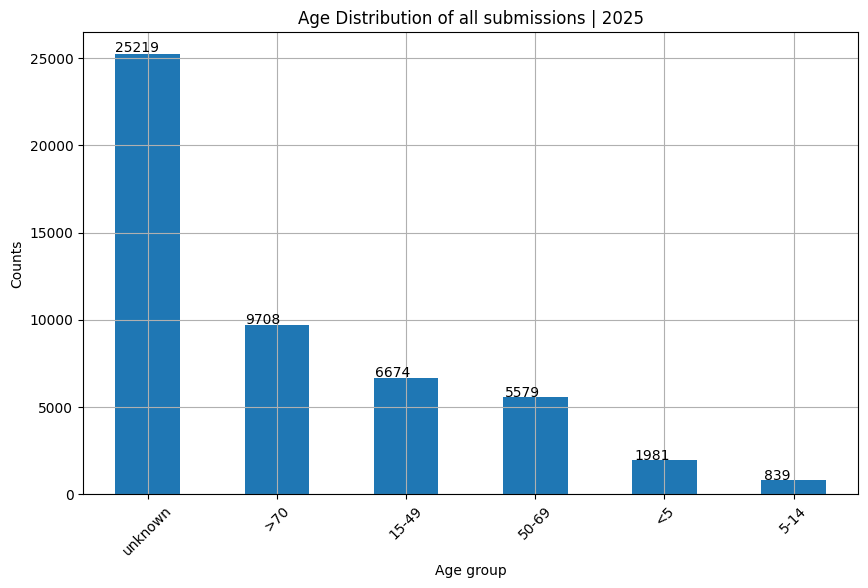

In [87]:
# Plot the bar chart
ax = df2["age_group"].value_counts().plot(kind='bar', figsize=(10, 6))
plt.grid()

# Annotate the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.xlabel('Age group')
plt.xticks(rotation=45)
plt.ylabel('Counts')
plt.title(f'Age Distribution of all submissions | {YEAR}')
plt.show()

In [88]:
import plotly.express as px

df_grouped = df2.groupby(["country", "age_group"]).size().reset_index(name="count")

df_grouped

,country,age_group,count
0,American Samoa,unknown,4
1,Argentina,15-49,13
2,Argentina,5-14,5
3,Argentina,50-69,7
4,Argentina,<5,21
...,...,...,...
269,United States,5-14,536
270,United States,50-69,2298
271,United States,<5,907
272,United States,>70,2164


In [89]:
fig = px.choropleth(
    df_grouped,
    locations="country",
    color="count",
    locationmode="country names",
    animation_frame="age_group",
    color_continuous_scale="YlGnBu",
    title=f"Age Group-wise Entries by Country | {YEAR}"
)
# Adjust the order of labels in the slider
# Desired order: '<5', '5-14', '15-49', '50-69', '>70', 'unknown'
desired_order = ['<5', '5-14', '15-49', '50-69', '>70', 'unknown']

# Find the current order of frames
current_order = [frame.name for frame in fig.frames]

# Create a mapping from label to frame
frame_dict = {frame.name: frame for frame in fig.frames}

# Reorder frames
fig.frames = tuple([frame_dict[label] for label in desired_order if label in frame_dict])

# Update slider steps order
for slider in fig.layout.sliders:
    step_dict = {step['label']: step for step in slider['steps']}
    slider['steps'] = [step_dict[label] for label in desired_order if label in step_dict]

fig.update_layout(title_x=0.5, width=1200, height=700)

fig.show()

In [90]:
fig = plot_dominant_choropleth(
    df2,
    value_column='age_group',
    color_map={
        '<5': '#e5f5e0',      # light green
        '5-14': '#a1d99b',
        '15-49': '#41ab5d',   # more contrast
        '50-69': '#238b45',   # more contrast
        '>70': '#005824',     # darkest green for high contrast
        'unknown': '#bdbdbd'  # gray for unknown
    },
    title="Dominant Age Group (Green Shades)",
    year=YEAR,
    )
fig.show()

In [91]:
df_merged.groupby("continent").agg({"num_entries_per_lakh":"mean","gender_m_per_lakh":"mean","gender_f_per_lakh":"mean",
                                    "gender_u_per_lakh":"mean","male_female_ratio":"mean", "status_per_lakh":"mean",})

,num_entries_per_lakh,gender_m_per_lakh,gender_f_per_lakh,gender_u_per_lakh,male_female_ratio,status_per_lakh
continent,,,,,,
Africa,0.598456,0.251855,0.345694,0.000906,0.608817,0.001554
Antarctica,NaN,NaN,NaN,NaN,NaN,NaN
Asia,0.998786,0.104031,0.091882,0.795085,1.030843,0.002917
Europe,3.602206,1.211232,1.585373,0.805600,1.006446,0.000765
North America,3.901506,1.285013,1.930838,0.685590,0.647880,0.004038
Oceania,6.951161,0.769636,0.970648,5.210878,0.936449,0.000000
South America,1.848358,0.268941,0.306679,1.272738,0.915120,0.001791
